# 1. Import Libraries & Load Dataset

In [1]:
import pandas as pd
import os
import pickle
import torch
from pathlib import Path
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments

BASE_DIR = Path.cwd().parents[1]
DATA_DIR = BASE_DIR / 'data'
MODEL_DIR = BASE_DIR / 'models' / 'distilbert_prod'
os.makedirs(MODEL_DIR, exist_ok=True)

INPUT_PATH = DATA_DIR / '(prod)data_train_master.csv'
train_df = pd.read_csv(INPUT_PATH)
print(f"Total train data: {len(train_df):,} rows")
display(train_df.head(5))

c:\Users\VICTUS\OneDrive\Documents\Edwin's_Project\Moofy\emovie\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total train data: 30,604 rows


,clean_text,emotion_label
0,"oh man, i saw a white forest cake the other da...",Surprise
1,wow the garbage one and the bank one are reall...,Surprise
2,pretty cool.,Joy
3,"wow, someones lived a sheltered life.",Joy
4,never seen an abandoned piss trolley at a bus ...,Fear


# 2. Training

## Data Splitting

In [2]:
X_train_text = train_df['clean_text'].astype(str).tolist()
y_train_text = train_df['emotion_label']

## Label Encoding

In [3]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_text)
num_classes = len(label_encoder.classes_)

## Tokenization

In [4]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

In [5]:
train_encodings = tokenizer(
    X_train_text, 
    truncation=True,    # Cuts Sequence > 60 tokens
    padding=True,       # Equalizes Sequence Lengths
    max_length=60
)

## Converting into PyTorch Dataset

In [6]:
class EmotionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = EmotionDataset(train_encodings, y_train_encoded)

## Installing Architecture

In [7]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', 
    num_labels=num_classes
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2939.88it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Fine-Tuning Model

In [8]:
training_args = TrainingArguments(
    output_dir=str(MODEL_DIR / 'results'), 
    num_train_epochs=5,
    per_device_train_batch_size=16, 
    learning_rate=5e-5,
    report_to="none",
    fp16=True
)

In [9]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset
)

## Training The Model

In [10]:
trainer.train() 

c:\Users\VICTUS\OneDrive\Documents\Edwin's_Project\Moofy\emovie\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,0.969883
1000,0.812057
1500,0.781714
2000,0.734565
2500,0.606536
3000,0.618509
3500,0.620852
4000,0.574840
4500,0.468141
5000,0.480607


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.26it/s]
c:\Users\VICTUS\OneDrive\Documents\Edwin's_Project\Moofy\emovie\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.36it/s]
c:\Users\VICTUS\OneDrive\Documents\Edwin's_Project\Moofy\emovie\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.73it/s]
c:\Users\VICTUS\OneDrive\Documents\Edwin's_Project\Moofy\emovie\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
W

TrainOutput(global_step=9565, training_loss=0.5158493432834145, metrics={'train_runtime': 10874.1678, 'train_samples_per_second': 14.072, 'train_steps_per_second': 0.88, 'total_flos': 2375578980532800.0, 'train_loss': 0.5158493432834145, 'epoch': 5.0})

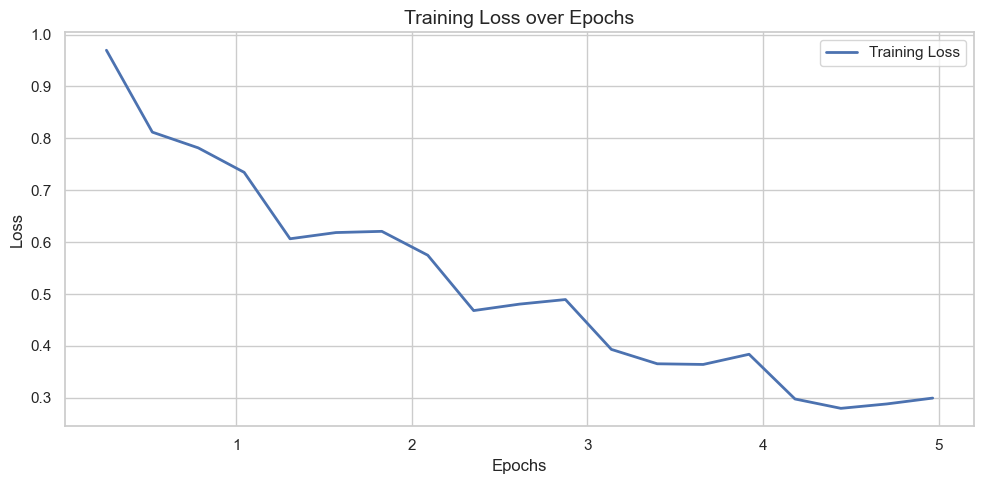

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

history = trainer.state.log_history

epochs = []
train_loss = []

for entry in history:
    if 'loss' in entry and 'epoch' in entry:
        epochs.append(entry['epoch'])
        train_loss.append(entry['loss'])

# Graphs
plt.figure(figsize=(10, 5))
if train_loss:
    plt.plot(epochs, train_loss, 'b-', label='Training Loss', linewidth=2)
    
plt.title('Training Loss over Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# 3. Dump Model

In [13]:
model.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

with open(MODEL_DIR / 'label_encoder.pkl', 'wb') as handle:
    pickle.dump(label_encoder, handle, protocol=pickle.HIGHEST_PROTOCOL)

Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.42s/it]
